# Raw (uncorrected) data processing (filename tag: `raw`)

This notebook reconstructs the **raw (uncorrected) measurement probabilities** and then computes the corresponding `P(α)` and `FI(α)` curves.

The released CSVs in `data/` used here are readout-corrected populations. To obtain the raw probabilities, we apply the readout confusion matrix `R`:

$$ P_{\mathrm{raw}} = P_{\mathrm{corr}}\,R^T. $$

## What this notebook does
1. **Load** readout-corrected probability time series from CSV.
2. **Reconstruct** raw probabilities by applying `R`.
3. **Convert** time samples `t` to rotation angle `α`.
4. **Compute** classical Fisher information (FI) using sliding-window local fits in `α`.
5. **Export** `α`, `P`, and `FI` to `data_analysis/*_alpha_P_FI_*_raw.csv`.
6. **Assemble** the singlet panels and averaged FI curve used in the SI.

```mermaid
flowchart LR
  in["Readout-corrected P_corr(t)\n(CSV in `data/`)"] --> raw["Apply confusion matrix R\n→ P_raw(t)"]
  raw --> alpha["Global fit → α(t)"]
  alpha --> fi["Sliding-window fits in α\n→ FI(α)"]
  fi --> csv["Write `data_analysis/*_alpha_P_FI_*_raw.csv`"]
  fi --> fig["Export SI figure panels"]
```

If you run into missing-file errors, confirm that `load_directory` points to the repository `data/` folder.


## Setup

This cell imports dependencies and resolves repository-relative paths so the notebook can be run from different working directories. By default, `load_directory` points at the repo's `data/` folder.


In [339]:
import os
from pathlib import Path

# Ensure relative paths work regardless of where the notebook is launched from.
_repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "data").exists():
        _repo_root = p
        break
if _repo_root is not None:
    os.chdir(_repo_root)
print("Working directory:", Path.cwd())

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Resolve the input data directory from common repository locations.
candidates = [
    Path("data"),
    Path("Data"),
    Path("..") / "data",
    Path("..") / "Data",
    Path.cwd() / "data",
    Path.cwd() / "Data",
    Path.cwd().parent / "data",
    Path.cwd().parent / "Data",
]
load_directory = None
for cand in candidates:
    if cand.exists():
        load_directory = str(cand)
        break

if not load_directory:
    load_directory = "data"

print("Loading data from:", load_directory)



Working directory: /Users/chellymac/projects/positronium-sensing
Loading data from: data


## Global plot style

For consistency across SI panels, we define shared Matplotlib style settings (fonts, line widths, marker styles, and `0, π, 2π` tick labels). Most plots in this notebook reuse these settings.


In [340]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style: axes + ticks (SI panel styling) ---
lw = 1
mpl.rcParams['axes.linewidth'] = lw
mpl.rcParams['lines.linewidth'] = lw
mpl.rcParams['xtick.major.width'] = lw
mpl.rcParams['ytick.major.width'] = lw
mpl.rcParams['xtick.major.size'] = 2
mpl.rcParams['ytick.major.size'] = 2
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['legend.fontsize'] = 7
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['mathtext.rm'] = 'STIXGeneral'
mpl.rcParams['mathtext.it'] = 'STIXGeneral:italic'
mpl.rcParams['mathtext.bf'] = 'STIXGeneral:bold'
import shutil
_HAS_TEX = all(shutil.which(cmd) for cmd in ('latex', 'dvipng', 'gs'))
mpl.rcParams['text.usetex'] = _HAS_TEX
mpl.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}\usepackage{helvet}\renewcommand{\familydefault}{\sfdefault}'
    r'\DeclareUnicodeCharacter{03B1}{\ensuremath{\alpha}}'
    if _HAS_TEX else ''
)

def _ket(state: str) -> str:
    if mpl.rcParams['text.usetex']:
        return rf'\left\lvert{{{state}}}\right\rangle'
    return rf'\left|{{{state}}}\right\rangle'

ket_psi = _ket(r'\Psi^-')
ket_xp = _ket('x+')
ket_zp = _ket('z+')
ket_1 = _ket('1')
ket_01 = _ket('01')

# Figure size (8.6 cm × 5 cm) -> inches
# Standard SI panel size used across exports.
fig_size = np.asarray([8.6, 5]) / 2.54

# Plot styles for the three rotation axes.
# We keep a consistent color/marker mapping across the SI:
#   x-axis rotation -> purple squares, y-axis rotation -> orange triangles, z-axis rotation -> gray circles.
style_x = dict(color="#6D00C9", marker="s", linestyle="-", markersize=5.0, label=r"$\hat{x}$")
style_y = dict(color="#F9AE2A", marker="^", linestyle="-", markersize=5.0, label=r"$\hat{y}$")
style_z = dict(color="#777777", marker="o", linestyle="-", markersize=5.0, label=r"$\hat{z}$")

# Common x-axis tick locations/labels (0, π, 2π).
# Many of the plots in this notebook show α on a grid that may extend beyond 2π,
# but these labels provide familiar reference points.
xticks = [0, np.pi, 2*np.pi]
xticklabels = [r"$0$", r"$\pi$", r"$2\pi$"]





## Shared single-qubit functions

These helper functions implement the classical Fisher information extraction for single-qubit probability curves.

- `t_to_alpha_with_params`: fits a decaying cosine model in time to infer the rotation rate, then converts `t → α`.
- `analyze_single_qubit_FI`: sliding-window FI for cosine-like signals.
- `analyze_single_qubit_FI_linear`: sliding-window FI for nearly-flat signals (linear local model).
- `save_alpha_P_FI`: exports `α`, `P`, and `FI` for downstream plotting notebooks.


In [341]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


def _sigmoid_stable(x):
    x = np.asarray(x, dtype=float)
    out = np.empty_like(x, dtype=float)
    pos = x >= 0.0
    out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
    exp_x = np.exp(x[~pos])
    out[~pos] = exp_x / (1.0 + exp_x)
    return out


def sigmoid_quadratic(alpha, q2, q1, q0):
    alpha = np.asarray(alpha, dtype=float)
    z = q2 * alpha * alpha + q1 * alpha + q0
    return _sigmoid_stable(z)


def sigmoid_quadratic_derivative(alpha, q2, q1, q0):
    alpha = np.asarray(alpha, dtype=float)
    p = sigmoid_quadratic(alpha, q2, q1, q0)
    dz_dalpha = 2.0 * q2 * alpha + q1
    return p * (1.0 - p) * dz_dalpha


def _initial_sigmoid_quadratic(alpha, p_obs, eps=1e-6):
    alpha = np.asarray(alpha, dtype=float)
    p_obs = np.asarray(p_obs, dtype=float)
    p_clip = np.clip(p_obs, eps, 1.0 - eps)
    logit = np.log(p_clip / (1.0 - p_clip))

    if len(alpha) >= 3 and np.ptp(alpha) > 0:
        try:
            q2, q1, q0 = np.polyfit(alpha, logit, 2)
            return np.array([q2, q1, q0], dtype=float)
        except (np.linalg.LinAlgError, ValueError):
            pass

    mean_p = float(np.mean(p_clip))
    q0 = np.log(mean_p / (1.0 - mean_p))
    return np.array([0.0, 0.0, q0], dtype=float)


def _fit_sigmoid_quadratic(alpha_subset, p_subset):
    p0 = _initial_sigmoid_quadratic(alpha_subset, p_subset)
    try:
        params, _ = curve_fit(
            sigmoid_quadratic,
            alpha_subset,
            p_subset,
            p0=p0,
            maxfev=20000,
        )
        return np.asarray(params, dtype=float)
    except RuntimeError:
        return p0


def _alpha_window_indices(alpha_sorted, alpha_window_size=0.8, step=1, min_points=3):
    alpha_sorted = np.asarray(alpha_sorted, dtype=float)
    if step < 1:
        raise ValueError("step must be at least 1.")
    if alpha_window_size is None:
        return []
    if alpha_window_size <= 0:
        raise ValueError("alpha_window_size must be > 0.")

    N = len(alpha_sorted)
    windows = []
    for start in range(0, N - min_points + 1, step):
        alpha_stop = alpha_sorted[start] + alpha_window_size
        end = int(np.searchsorted(alpha_sorted, alpha_stop, side="right"))
        if end - start >= min_points:
            windows.append((start, end))
    return windows


def analyze_single_qubit_FI(
    alpha_data,
    P_01,
    window_size=30,
    step=1,
    n_alpha_points=300,
    make_plot=True,
    label=None,
    eps=1e-9,
    alpha_grid_points=100,
    alpha_window_size=0.8,
):
    """
    Sliding-window Fisher information analysis in alpha-space using local
    sigmoid(quadratic) fits:

        P(alpha) = sigmoid(q2 * alpha^2 + q1 * alpha + q0)

    with analytic derivative

        dP/dalpha = P(1-P) * (2*q2*alpha + q1)

    The FI is computed as

        FI(alpha) = (dP/dalpha)^2 / [P(alpha) * (1-P(alpha))].

    Windows are built by alpha span (default 0.8 rad). The legacy index-space
    `window_size` is kept only as a fallback when alpha windows cannot be built.
    """

    alpha_data = np.asarray(alpha_data, float)
    P_01 = np.asarray(P_01, float)

    if alpha_data.shape != P_01.shape:
        raise ValueError("alpha_data and P_01 must have the same shape.")

    finite = np.isfinite(alpha_data) & np.isfinite(P_01)
    alpha_pos = alpha_data[finite]
    P_pos = P_01[finite]

    order = np.argsort(alpha_pos)
    alpha_pos = alpha_pos[order]
    P_pos = P_pos[order]

    N = len(alpha_pos)
    if N < 3:
        raise ValueError("Need at least 3 finite points for sigmoid(quadratic) FI analysis.")

    windows = _alpha_window_indices(
        alpha_pos,
        alpha_window_size=alpha_window_size,
        step=step,
        min_points=3,
    )

    if not windows:
        if window_size < 3:
            raise ValueError("window_size must be at least 3.")
        if window_size > N:
            raise ValueError(f"window_size ({window_size}) cannot exceed number of points ({N}).")
        windows = [(start, start + window_size) for start in range(0, N - window_size + 1, step)]

    global_fit_params = _fit_sigmoid_quadratic(alpha_pos, P_pos)
    P_global = sigmoid_quadratic(alpha_pos, *global_fit_params)

    alpha_segments = []
    P_segments = []
    FI_segments = []

    for start, end in windows:
        alpha_subset = alpha_pos[start:end]
        P_subset = P_pos[start:end]

        params_loc = _fit_sigmoid_quadratic(alpha_subset, P_subset)

        alpha_fine = np.linspace(alpha_subset.min(), alpha_subset.max(), n_alpha_points)
        P_alpha = sigmoid_quadratic(alpha_fine, *params_loc)
        dP_dalpha = sigmoid_quadratic_derivative(alpha_fine, *params_loc)

        denom = P_alpha * (1.0 - P_alpha)
        FI_alpha = np.full_like(P_alpha, np.nan, dtype=float)
        mask = denom > eps
        FI_alpha[mask] = (dP_dalpha[mask] ** 2) / denom[mask]

        alpha_segments.append(alpha_fine)
        P_segments.append(P_alpha)
        FI_segments.append(FI_alpha)

    if len(alpha_segments) == 0:
        raise RuntimeError("No windows were produced. Check alpha_window_size/window_size/step.")

    alpha_min = min(seg.min() for seg in alpha_segments)
    alpha_max = max(seg.max() for seg in alpha_segments)
    alpha_grid = np.linspace(alpha_min, alpha_max, alpha_grid_points)

    FI_grid_list = []
    for alpha_seg, FI_seg in zip(alpha_segments, FI_segments):
        FI_interp = np.full_like(alpha_grid, np.nan, dtype=float)
        mask = (alpha_grid >= alpha_seg.min()) & (alpha_grid <= alpha_seg.max())
        if np.any(mask):
            FI_interp[mask] = np.interp(alpha_grid[mask], alpha_seg, FI_seg)
        FI_grid_list.append(FI_interp)

    FI_stack = np.vstack(FI_grid_list)
    FI_avg = np.nanmean(FI_stack, axis=0)

    if make_plot:
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        for idx, (alpha_seg, P_seg) in enumerate(zip(alpha_segments, P_segments)):
            fit_label = 'Piecewise sigmoid(quadratic) fits' if idx == 0 else None
            plt.plot(alpha_seg, P_seg, color='0.70', linewidth=1.0, alpha=0.35, label=fit_label, zorder=1)
        plt.plot(alpha_pos, P_pos, 'bo', markersize=3, label='Data', zorder=3)
        plt.xlabel(r'$\alpha$')
        plt.ylabel(r'$P(\alpha)$')
        title_left = "Single-qubit: P vs alpha (piecewise local fits)"
        if label:
            title_left += f" ({label})"
        plt.title(title_left)
        plt.ylim(0, 1)
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(alpha_grid, FI_avg, 'm-')
        plt.xlabel(r'$\alpha$')
        plt.ylabel('FI(alpha)')
        plt.title("Single-qubit: averaged FI vs alpha")
        if np.any(np.isfinite(FI_avg)):
            plt.ylim(-0.2, 1.1 * np.nanmax(FI_avg))
        plt.tight_layout()
        plt.show()

    return {
        "alpha_grid": alpha_grid,
        "FI_avg": FI_avg,
        "FI_stack": FI_stack,
        "alpha_segments": alpha_segments,
        "P_segments": P_segments,
        "FI_segments": FI_segments,
        "global_fit_params": tuple(global_fit_params),
        "alpha_window_size": alpha_window_size,
        "window_indices": windows,
    }


In [342]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


def analyze_single_qubit_FI_linear(
    alpha_data,
    P_01,
    window_size=30,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label=None,
    eps=1e-9,
    alpha_window_size=0.8,
):
    """
    Backward-compatible wrapper for legacy linear-path calls.

    This now uses the same sigmoid(quadratic) local model as
    analyze_single_qubit_FI, including analytic derivatives and FI.
    """

    return analyze_single_qubit_FI(
        alpha_data=alpha_data,
        P_01=P_01,
        window_size=window_size,
        step=step,
        n_alpha_points=n_alpha_points,
        make_plot=make_plot,
        label=label,
        eps=eps,
        alpha_grid_points=n_alpha_points,
        alpha_window_size=alpha_window_size,
    )


In [343]:
def save_alpha_P_FI(basename, alpha, P, FI, save_dir, date_suffix):
    """
    Save a 3-column CSV: alpha, P, FI
    filename = f"{basename}_alpha_P_FI_{date_suffix}.csv"
    """
    alpha = np.asarray(alpha, float)
    P     = np.asarray(P,     float)
    FI    = np.asarray(FI,    float)

    data = np.column_stack([alpha, P, FI])

    filename = f"{basename}_alpha_P_FI_{date_suffix}.csv"
    save_path = os.path.join(save_dir, filename)
    os.makedirs(save_dir, exist_ok=True)

    np.savetxt(
        save_path,
        data,
        delimiter=",",
        header="alpha_rad,P,FI",
        comments=""
    )

    print(f"Saved {basename} α,P,FI to:", save_path)
    return save_path



In [344]:
def t_to_alpha_with_params(t_list, P_01, frequency_factor, initial_guess_global):
    """
    Global fit in time to get A, Omega, tau, y0, then convert t -> alpha.
    Returns:
        angle_list, tau, params = (A, Omega, tau, y0)
    """
    def fit_func_t(t, A, Omega, tau, y0):
        return A * np.cos(Omega * t) * np.exp(-t / tau) + y0

    params, _ = curve_fit(fit_func_t, t_list, P_01, p0=initial_guess_global)
    A, Omega, tau, y0 = params

    angle_list = t_list * Omega / frequency_factor
    return angle_list, tau, params


## Readout matrices and raw reconstruction

Raw (uncorrected) measurement probabilities are reconstructed by applying the readout confusion matrix `R`:

$$ P_{\mathrm{raw}} = P_{\mathrm{corr}} R^T. $$

The matrices below are the readout confusion matrices measured for this dataset (single-qubit for Q1/Q2 and two-qubit for the singlet readout). They are included here as numerical constants so the raw-reconstruction step is explicit and reproducible.


In [345]:
import numpy as np

# Single-qubit readout matrices
R_Q1 = np.array([[0.976, 0.041],
                 [0.024, 0.959]])

R_Q2 = np.array([[0.928, 0.055],
                 [0.072, 0.945]])

# Two-qubit readout matrix (computational basis ordering |00>,|01>,|10>,|11>)
R_2q = np.array([
    [0.911, 0.052, 0.034, 0.002],
    [0.068, 0.920, 0.004, 0.042],
    [0.019, 0.001, 0.892, 0.055],
    [0.002, 0.027, 0.071, 0.900],
])

# Map corrected populations -> raw measured populations (single-qubit)
def apply_readout_matrix(P_corr, R):
    P_corr = np.asarray(P_corr, float)
    R      = np.asarray(R,      float)
    return P_corr @ R.T

# Map corrected populations -> raw measured populations (multi-qubit)
def apply_readout_matrix_general(P_corr, R):
    P_corr = np.asarray(P_corr, float)
    R      = np.asarray(R, float)
    if P_corr.shape[1] != R.shape[1]:
        raise ValueError("Mismatch between column count in P_corr and R.")
    return P_corr @ R.T



## Unentangled single-qubit data (Q1) — raw (uncorrected)

We load readout-fidelity-corrected populations for Q1 and then apply the Q1 readout matrix to reconstruct raw measured probabilities.


## Q1 baseline (raw reconstruction + FI)
This section reconstructs Q1 raw measured probabilities from the readout-corrected populations and then computes `FI(α)` for each rotation axis.


In [346]:
import os
import pandas as pd

# Directory containing the input CSV files.
# (load_directory set in the setup cell above)

# Define the experiment name and date suffix
exp_name_xyz = 'Ux_Uy_Uz_pre_xz_meas_xz'
date_suffix = '1218'  # Dataset tag used in the released filenames.

# Load the data from the CSV files
t_list = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_t_list_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q1_Ux = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q1_Ux_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q1_Uy = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q1_Uy_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q1_Uz = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q1_Uz_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q2_Ux = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q2_Ux_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q2_Uy = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q2_Uy_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q2_Uz = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q2_Uz_{date_suffix}.csv"), delimiter=",", skiprows=1)



raw shapes: (153, 2) (153, 2) (153, 2)


/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_96763/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


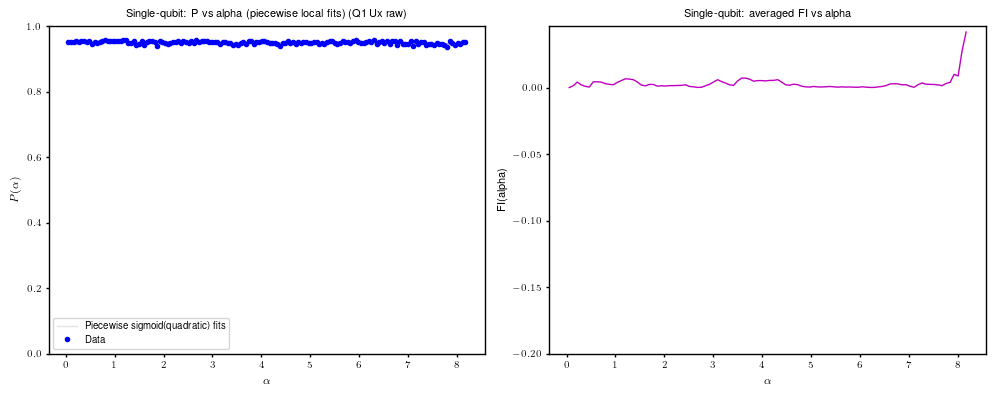

/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_96763/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


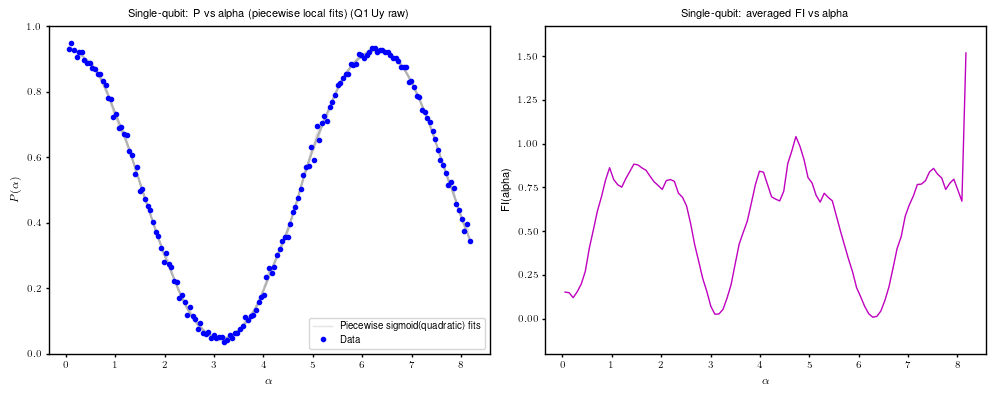

/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_96763/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


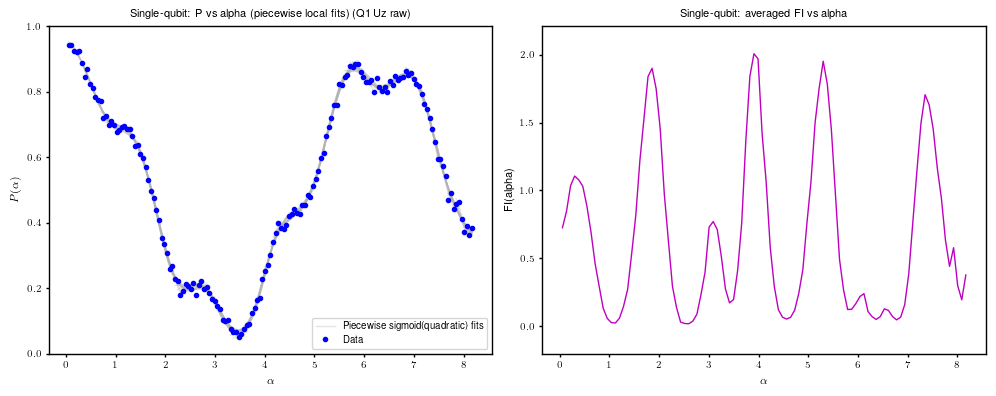

Saved Q1_Ux α,P,FI to: data_analysis/Q1_Ux_alpha_P_FI_1218_raw.csv
Saved Q1_Uy α,P,FI to: data_analysis/Q1_Uy_alpha_P_FI_1218_raw.csv
Saved Q1_Uz α,P,FI to: data_analysis/Q1_Uz_alpha_P_FI_1218_raw.csv


'data_analysis/Q1_Uz_alpha_P_FI_1218_raw.csv'

In [347]:
import numpy as np

def apply_readout_matrix(P_corr, R):
    """
    Map corrected populations -> raw measured populations.

    P_corr : shape (T, 2)
        Columns: [P(|0>), P(|1>)] after readout correction
    R : shape (2, 2)
        Readout/confusion matrix with
        R[meas_state, prepared_state] = P(measured | prepared)

    Returns
    -------
    P_raw : shape (T, 2)
        Raw measured probabilities for each time point.
    """
    P_corr = np.asarray(P_corr, float)
    R      = np.asarray(R,      float)

    # row-wise: (T,2) @ (2,2)^T -> (T,2)
    P_raw = P_corr @ R.T
    return P_raw


# ===============================================================
# 0) Readout → RAW probabilities
# ===============================================================
R_Q1 = np.array([[0.976, 0.041],
                 [0.024, 0.959]])

P_Q1_Ux_raw = apply_readout_matrix(P_Q1_Ux, R_Q1)
P_Q1_Uy_raw = apply_readout_matrix(P_Q1_Uy, R_Q1)
P_Q1_Uz_raw = apply_readout_matrix(P_Q1_Uz, R_Q1)

P_Q1_Ux_01_raw = P_Q1_Ux_raw[:, 1]
P_Q1_Uy_01_raw = P_Q1_Uy_raw[:, 1]
P_Q1_Uz_01_raw = P_Q1_Uz_raw[:, 1]

print("raw shapes:", P_Q1_Ux_raw.shape, P_Q1_Uy_raw.shape, P_Q1_Uz_raw.shape)


# ===============================================================
# 1) Convert t → α using Uy (same alpha_Q1 for all axes)
# ===============================================================
frequency_factor = 1
initial_guess_global = [0.5, 0.02, 10000, 0.5]

alpha_Q1_raw, tau_raw, params_raw = t_to_alpha_with_params(
    t_list,
    P_Q1_Uy_01_raw,     # Uy defines α(t)
    frequency_factor,
    initial_guess_global
)


# ===============================================================
# 2) FI extraction (Ux uses linear FI, Uy/Uz use cosine FI)
# ===============================================================

# ---- Q1 Ux RAW (linear model) ----
res_Q1_Ux_raw = analyze_single_qubit_FI_linear(
    alpha_data=alpha_Q1_raw,
    P_01=P_Q1_Ux_01_raw,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q1 Ux raw"
)
alpha_grid_Q1_Ux_raw = res_Q1_Ux_raw["alpha_grid"]
FI_Q1_Ux_raw         = res_Q1_Ux_raw["FI_avg"]

# ---- Q1 Uy RAW (cosine model) ----
res_Q1_Uy_raw = analyze_single_qubit_FI(
    alpha_data=alpha_Q1_raw,
    P_01=P_Q1_Uy_01_raw,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q1 Uy raw"
)
alpha_grid_Q1_Uy_raw = res_Q1_Uy_raw["alpha_grid"]
FI_Q1_Uy_raw         = res_Q1_Uy_raw["FI_avg"]

# ---- Q1 Uz RAW (cosine model) ----
res_Q1_Uz_raw = analyze_single_qubit_FI(
    alpha_data=alpha_Q1_raw,
    P_01=P_Q1_Uz_01_raw,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q1 Uz raw"
)
alpha_grid_Q1_Uz_raw = res_Q1_Uz_raw["alpha_grid"]
FI_Q1_Uz_raw         = res_Q1_Uz_raw["FI_avg"]


# ===============================================================
# 3) Interpolate raw P(α) onto FI α-grid
# ===============================================================

P_Q1_Ux_01_raw_interp = np.interp(alpha_grid_Q1_Ux_raw, alpha_Q1_raw, P_Q1_Ux_01_raw)
P_Q1_Uy_01_raw_interp = np.interp(alpha_grid_Q1_Uy_raw, alpha_Q1_raw, P_Q1_Uy_01_raw)
P_Q1_Uz_01_raw_interp = np.interp(alpha_grid_Q1_Uz_raw, alpha_Q1_raw, P_Q1_Uz_01_raw)


# ===============================================================
# 4) Save CSV files
# ===============================================================

save_dir = "data_analysis"
date_suffix_raw = "1218_raw"

save_alpha_P_FI(
    basename="Q1_Ux",
    alpha=alpha_grid_Q1_Ux_raw,
    P=P_Q1_Ux_01_raw_interp,
    FI=FI_Q1_Ux_raw,
    save_dir=save_dir,
    date_suffix=date_suffix_raw
)

save_alpha_P_FI(
    basename="Q1_Uy",
    alpha=alpha_grid_Q1_Uy_raw,
    P=P_Q1_Uy_01_raw_interp,
    FI=FI_Q1_Uy_raw,
    save_dir=save_dir,
    date_suffix=date_suffix_raw
)

save_alpha_P_FI(
    basename="Q1_Uz",
    alpha=alpha_grid_Q1_Uz_raw,
    P=P_Q1_Uz_01_raw_interp,
    FI=FI_Q1_Uz_raw,
    save_dir=save_dir,
    date_suffix=date_suffix_raw
)


## Unentangled single-qubit data (Q2) — raw (uncorrected)

Same workflow as Q1, but for the second qubit.


In [348]:
import os
import pandas as pd

# Define the directory where files are saved
# (load_directory set in the setup cell above)

# Define the experiment name and date suffix
exp_name_xyz = 'Ux_Uy_Uz_pre_xz_meas_xz'
date_suffix = '1218'  # Dataset tag used in the released filenames.

# Load the data from the CSV files
t_list = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_t_list_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q2_Ux = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q2_Ux_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q2_Uy = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q2_Uy_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q2_Uz = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q2_Uz_{date_suffix}.csv"), delimiter=",", skiprows=1)



In [349]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def analyze_single_qubit_FI_q2(
    alpha_data,
    P_01,
    window_size=30,
    step=1,
    n_alpha_points=300,
    make_plot=True,
    label=None,
    eps=1e-9,
    alpha_window_size=0.8,
):
    """
    Backward-compatible Q2 wrapper.

    Uses the same sigmoid(quadratic) sliding-window FI pipeline as
    analyze_single_qubit_FI.
    """

    return analyze_single_qubit_FI(
        alpha_data=alpha_data,
        P_01=P_01,
        window_size=window_size,
        step=step,
        n_alpha_points=n_alpha_points,
        make_plot=make_plot,
        label=label,
        eps=eps,
        alpha_grid_points=n_alpha_points,
        alpha_window_size=alpha_window_size,
    )


## Q2 baseline (raw reconstruction + FI)
This section reconstructs Q2 raw measured probabilities from the readout-corrected populations and then computes `FI(α)` for each rotation axis.


Q2 raw shapes: (153, 2) (153, 2) (153, 2)


/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_96763/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


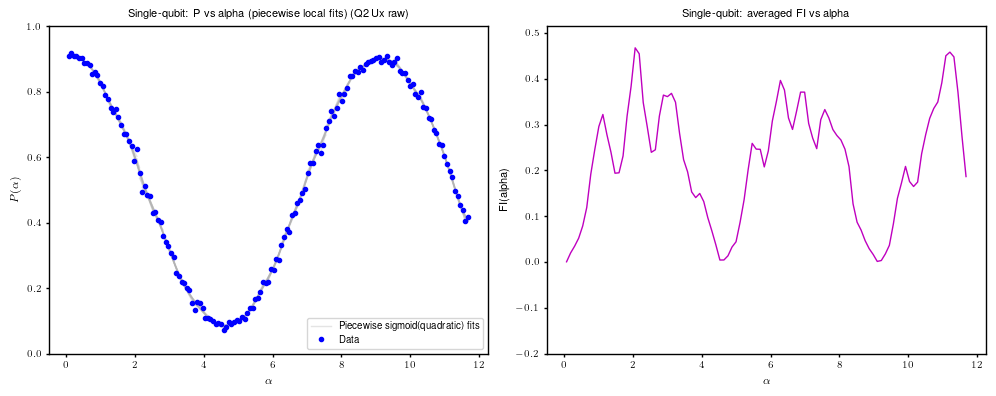

/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_96763/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


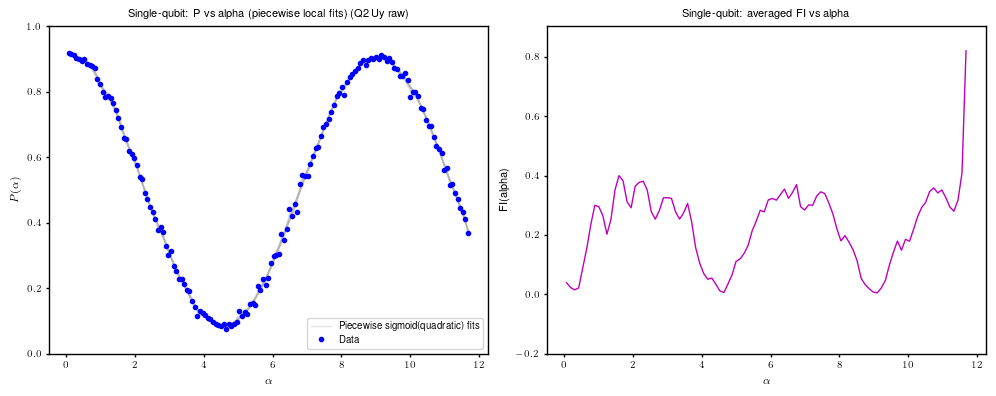

/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_96763/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


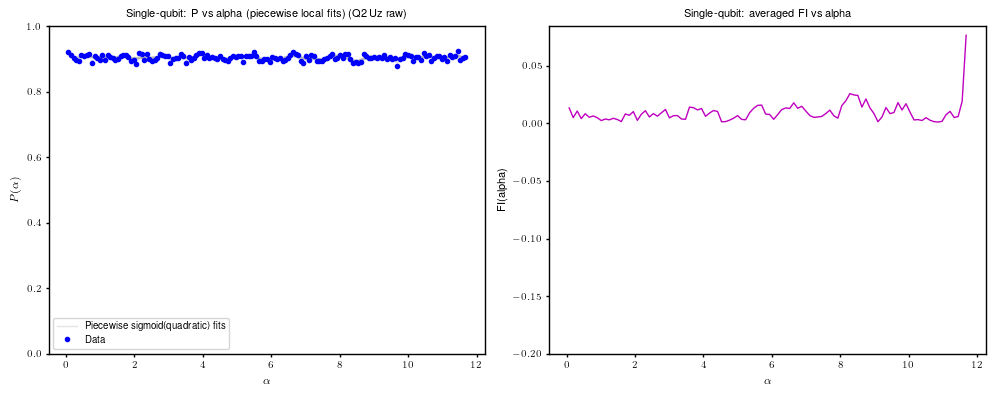

Saved Q2_Ux α,P,FI to: data_analysis/Q2_Ux_alpha_P_FI_1218_raw.csv
Saved Q2_Uy α,P,FI to: data_analysis/Q2_Uy_alpha_P_FI_1218_raw.csv
Saved Q2_Uz α,P,FI to: data_analysis/Q2_Uz_alpha_P_FI_1218_raw.csv


'data_analysis/Q2_Uz_alpha_P_FI_1218_raw.csv'

In [350]:
import numpy as np

def apply_readout_matrix(P_corr, R):
    """
    Map corrected populations -> raw measured populations.

    P_corr : shape (T, 2)
        Columns: [P(|0>), P(|1>)] after readout correction
    R : shape (2, 2)
        Readout/confusion matrix with
        R[meas_state, prepared_state] = P(measured | prepared)

    Returns
    -------
    P_raw : shape (T, 2)
        Raw measured probabilities for each time point.
    """
    P_corr = np.asarray(P_corr, float)
    R      = np.asarray(R,      float)

    # row-wise: (T,2) @ (2,2)^T -> (T,2)
    P_raw = P_corr @ R.T
    return P_raw


# ===============================================================
# 0) Readout → RAW probabilities for Q2
# ===============================================================
# Q2 single-qubit readout confusion matrix R (measured in calibration).
R_Q2 = np.array([[0.928, 0.055],
                 [0.072, 0.945]])

# P_Q2_Ux, P_Q2_Uy, P_Q2_Uz each have shape (T, 2): [P0_corr, P1_corr]
P_Q2_Ux_raw = apply_readout_matrix(P_Q2_Ux, R_Q2)
P_Q2_Uy_raw = apply_readout_matrix(P_Q2_Uy, R_Q2)
P_Q2_Uz_raw = apply_readout_matrix(P_Q2_Uz, R_Q2)

P_Q2_Ux_01_raw = P_Q2_Ux_raw[:, 0]
P_Q2_Uy_01_raw = P_Q2_Uy_raw[:, 0]
P_Q2_Uz_01_raw = P_Q2_Uz_raw[:, 0]

print("Q2 raw shapes:", P_Q2_Ux_raw.shape, P_Q2_Uy_raw.shape, P_Q2_Uz_raw.shape)


# ===============================================================
# 1) Convert t → α using Uy (defines common α grid for Q2)
# ===============================================================
frequency_factor = 1
initial_guess_global = [0.5, 0.02, 10000, 0.5]

alpha_Q2_raw, tau_Q2_raw, params_Q2_raw = t_to_alpha_with_params(
    t_list,
    P_Q2_Uy_01_raw,     # Uy defines α(t) for Q2
    frequency_factor,
    initial_guess_global
)


# ===============================================================
# 2) FI extraction (Q2 Ux / Uy cosine, Uz linear)
# ===============================================================

# ---- Q2 Ux RAW (cosine model) ----
res_Q2_Ux_raw = analyze_single_qubit_FI_q2(
    alpha_data=alpha_Q2_raw,
    P_01=P_Q2_Ux_01_raw,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q2 Ux raw"
)
alpha_grid_Q2_Ux_raw = res_Q2_Ux_raw["alpha_grid"]
FI_Q2_Ux_raw         = res_Q2_Ux_raw["FI_avg"]

# ---- Q2 Uy RAW (cosine model) ----
res_Q2_Uy_raw = analyze_single_qubit_FI_q2(
    alpha_data=alpha_Q2_raw,
    P_01=P_Q2_Uy_01_raw,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q2 Uy raw"
)
alpha_grid_Q2_Uy_raw = res_Q2_Uy_raw["alpha_grid"]
FI_Q2_Uy_raw         = res_Q2_Uy_raw["FI_avg"]

# ---- Q2 Uz RAW (linear / flat model) ----
res_Q2_Uz_raw = analyze_single_qubit_FI_linear(
    alpha_data=alpha_Q2_raw,
    P_01=P_Q2_Uz_01_raw,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q2 Uz raw"
)
alpha_grid_Q2_Uz_raw = res_Q2_Uz_raw["alpha_grid"]
FI_Q2_Uz_raw         = res_Q2_Uz_raw["FI_avg"]


# ===============================================================
# 3) Interpolate raw P(α) onto each FI α-grid
# ===============================================================
P_Q2_Ux_01_raw_interp = np.interp(
    alpha_grid_Q2_Ux_raw,
    alpha_Q2_raw,
    P_Q2_Ux_01_raw
)

P_Q2_Uy_01_raw_interp = np.interp(
    alpha_grid_Q2_Uy_raw,
    alpha_Q2_raw,
    P_Q2_Uy_01_raw
)

P_Q2_Uz_01_raw_interp = np.interp(
    alpha_grid_Q2_Uz_raw,
    alpha_Q2_raw,
    P_Q2_Uz_01_raw
)


# ===============================================================
# 4) Save CSV files (Q2 raw)
# ===============================================================
save_dir = "data_analysis"
date_suffix_raw = "1218_raw"

save_alpha_P_FI(
    basename="Q2_Ux",
    alpha=alpha_grid_Q2_Ux_raw,
    P=P_Q2_Ux_01_raw_interp,
    FI=FI_Q2_Ux_raw,
    save_dir=save_dir,
    date_suffix=date_suffix_raw
)

save_alpha_P_FI(
    basename="Q2_Uy",
    alpha=alpha_grid_Q2_Uy_raw,
    P=P_Q2_Uy_01_raw_interp,
    FI=FI_Q2_Uy_raw,
    save_dir=save_dir,
    date_suffix=date_suffix_raw
)

save_alpha_P_FI(
    basename="Q2_Uz",
    alpha=alpha_grid_Q2_Uz_raw,
    P=P_Q2_Uz_01_raw_interp,
    FI=FI_Q2_Uz_raw,
    save_dir=save_dir,
    date_suffix=date_suffix_raw
)


## Shared singlet-state functions

These helper functions implement FI extraction for the two-qubit singlet-state analysis using a cosine fit in `α` within sliding windows.

In this notebook, we focus on the probability of a specific computational-basis outcome (see below) as a function of `α`.


In [351]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


def analyze_singlet_FI_alpha(
    alpha_data,
    P_01,
    subset_indices=None,
    n_alpha_points=1000,
    make_plot=True,
    eps=1e-9,
):
    """
    Local singlet FI extraction in alpha-space with a sigmoid(quadratic) model.
    """

    alpha_data = np.asarray(alpha_data, float)
    P_01 = np.asarray(P_01, float)

    if subset_indices is None:
        start, end = 0, len(alpha_data)
    else:
        start, end = subset_indices

    alpha_subset = alpha_data[start:end]
    P_subset = P_01[start:end]

    finite = np.isfinite(alpha_subset) & np.isfinite(P_subset)
    alpha_subset = alpha_subset[finite]
    P_subset = P_subset[finite]

    if len(alpha_subset) < 3:
        raise ValueError("Subset too small for sigmoid(quadratic) fit.")

    order = np.argsort(alpha_subset)
    alpha_subset = alpha_subset[order]
    P_subset = P_subset[order]

    params_subset = _fit_sigmoid_quadratic(alpha_subset, P_subset)

    alpha_fine = np.linspace(alpha_subset.min(), alpha_subset.max(), n_alpha_points)
    P_alpha = sigmoid_quadratic(alpha_fine, *params_subset)
    dP_dalpha = sigmoid_quadratic_derivative(alpha_fine, *params_subset)

    denom = P_alpha * (1.0 - P_alpha)
    FI_alpha = np.full_like(P_alpha, np.nan)
    mask = denom > eps
    FI_alpha[mask] = (dP_dalpha[mask] ** 2) / denom[mask]

    if make_plot:
        xticks = [0, np.pi, 2*np.pi]
        xticklabels = [r"$0$", r"$\pi$", r"$2\pi$"]
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.plot(alpha_data, P_01, color=style_x['color'], marker=style_x['marker'], linestyle=style_x['linestyle'], markersize=style_x['markersize'], label='Measured P(alpha)')
        plt.plot(alpha_subset, P_subset, color=style_y['color'], marker=style_y['marker'], linestyle=style_y['linestyle'], markersize=style_y['markersize'], label='Windowed subset')
        plt.plot(alpha_fine, P_alpha, color=style_z['color'], marker=style_z['marker'], linestyle=style_z['linestyle'], markersize=style_z['markersize'], label='Subset fit: sigmoid(quadratic)')
        plt.xlabel(r'$\alpha$ (radians)')
        plt.ylabel('P(alpha)')
        plt.xticks(xticks, xticklabels)
        plt.ylim(0, 1)
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(alpha_fine, FI_alpha, color=style_z['color'], marker=style_z['marker'], linestyle=style_z['linestyle'], markersize=style_z['markersize'])
        plt.xlabel(r'$\alpha$ (radians)')
        plt.ylabel('FI(alpha)')
        plt.xticks(xticks, xticklabels)
        if np.nanmax(FI_alpha) > 0:
            plt.ylim(-0.2, np.nanmax(FI_alpha) * 1.1)
        plt.tight_layout()
        plt.show()

    return {
        "subset_fit_params": tuple(params_subset),
        "alpha_data": alpha_data,
        "alpha_subset": alpha_subset,
        "alpha_fine": alpha_fine,
        "P_alpha": P_alpha,
        "dP_dalpha": dP_dalpha,
        "FI_alpha": FI_alpha,
    }


In [352]:
import numpy as np
import matplotlib.pyplot as plt


def analyze_singlet_FI(
    alpha_data,
    P_01,
    window_size=30,
    step=1,
    n_alpha_points=300,
    make_plot=True,
    alpha_window_size=0.8,
):
    """
    Sliding-window singlet FI analysis in alpha-space using sigmoid(quadratic)
    local fits and analytic derivatives.
    """

    alpha_data = np.asarray(alpha_data, float)
    P_01 = np.asarray(P_01, float)

    if len(alpha_data) != len(P_01):
        raise ValueError("alpha_data and P_01 must have the same length.")

    finite = np.isfinite(alpha_data) & np.isfinite(P_01)
    alpha_sorted = alpha_data[finite]
    P_sorted = P_01[finite]

    order = np.argsort(alpha_sorted)
    alpha_sorted = alpha_sorted[order]
    P_sorted = P_sorted[order]

    N = len(alpha_sorted)
    if N < 3:
        raise ValueError("Need at least 3 finite points for singlet FI analysis.")

    windows = _alpha_window_indices(
        alpha_sorted,
        alpha_window_size=alpha_window_size,
        step=step,
        min_points=3,
    )

    if not windows:
        if window_size < 3:
            raise ValueError("window_size must be at least 3 points.")
        if window_size > N:
            raise ValueError("window_size cannot exceed number of data points.")
        windows = [(start, start + window_size) for start in range(0, N - window_size + 1, step)]

    alpha_segments = []
    P_segments = []
    FI_segments = []

    for start, end in windows:
        res = analyze_singlet_FI_alpha(
            alpha_data=alpha_sorted,
            P_01=P_sorted,
            subset_indices=(start, end),
            n_alpha_points=n_alpha_points,
            make_plot=False,
        )

        alpha_segments.append(res["alpha_fine"])
        P_segments.append(res["P_alpha"])
        FI_segments.append(res["FI_alpha"])

    if len(alpha_segments) == 0:
        raise RuntimeError("No windows were generated; check alpha_window_size/window_size/step.")

    alpha_min = min(seg.min() for seg in alpha_segments)
    alpha_max = max(seg.max() for seg in alpha_segments)
    alpha_grid = np.linspace(alpha_min, alpha_max, 100)

    FI_grid_list = []
    for alpha_seg, FI_seg in zip(alpha_segments, FI_segments):
        FI_interp = np.full_like(alpha_grid, np.nan, dtype=float)
        mask = (alpha_grid >= alpha_seg.min()) & (alpha_grid <= alpha_seg.max())
        if np.any(mask):
            FI_interp[mask] = np.interp(alpha_grid[mask], alpha_seg, FI_seg)
        FI_grid_list.append(FI_interp)

    FI_stack = np.vstack(FI_grid_list)
    FI_avg = np.nanmean(FI_stack, axis=0)

    if make_plot:
        xticks = [0, np.pi, 2*np.pi]
        xticklabels = [r"$0$", r"$\pi$", r"$2\pi$"]
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        for idx, (alpha_seg, P_seg) in enumerate(zip(alpha_segments, P_segments)):
            fit_label = 'Piecewise sigmoid(quadratic) fits' if idx == 0 else None
            plt.plot(alpha_seg, P_seg, color=style_z['color'], linewidth=1.0, alpha=0.25, label=fit_label, zorder=1)
        plt.plot(alpha_sorted, P_sorted, color=style_x['color'], marker=style_x['marker'], linestyle=style_x['linestyle'], markersize=style_x['markersize'], label='Measured P(alpha)', zorder=3)
        plt.xlabel(r'$\alpha$ (radians)')
        plt.ylabel('P(alpha)')
        plt.xticks(xticks, xticklabels)
        plt.title("Singlet: P vs alpha")
        plt.ylim(0, 1)
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(alpha_grid, FI_avg, color=style_z['color'], marker=style_z['marker'], linestyle=style_z['linestyle'], markersize=style_z['markersize'])
        plt.xlabel(r'$\alpha$ (radians)')
        plt.ylabel('FI(alpha)')
        plt.xticks(xticks, xticklabels)
        if np.any(np.isfinite(FI_avg)):
            plt.ylim(-0.2, 1.1 * np.nanmax(FI_avg))
        plt.title("Singlet: averaged FI vs alpha (sliding windows)")

        plt.tight_layout()
        plt.show()

    return {
        "alpha_grid": alpha_grid,
        "FI_avg": FI_avg,
        "FI_stack": FI_stack,
        "alpha_segments": alpha_segments,
        "P_segments": P_segments,
        "FI_segments": FI_segments,
        "alpha_window_size": alpha_window_size,
        "window_indices": windows,
    }


## Singlet dataset (rotations about $\hat{x}$) — raw (uncorrected)

We apply the two-qubit readout matrix to reconstruct raw measurement probabilities, then compute FI in α.


In [353]:
import os
import pandas as pd

# Directory containing the input CSV files.
# (load_directory set in the setup cell above)

# Experiment identifier and date tag used in the CSV filenames.
# The date tag (e.g. "1218") is part of the filename and does not affect the analysis logic.
exp_name_z = 'singlet_Ux'
date_suffix = '1218'  # Dataset tag used in the released filenames.

# Load readout-fidelity-corrected probability time series from CSV.
t_list_Ux = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_t_list_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Ux = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_P_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_01_Ux = P_Ux[:,1]  # interpret column 1 as P(|01⟩)



In [354]:
# 1) Convert experimental time samples t -> rotation angle α (radians)
# We fit a decaying cosine in time to infer the oscillation frequency Ω, then define α = Ω t / frequency_factor.
# The frequency_factor is a convention used in the original analysis notebooks (kept here for consistency).
frequency_factor = 2.0
initial_guess_global = [0.5, 0.025, 10000, 0.5]

alpha_data_Ux, tau_Ux, params_Ux = t_to_alpha_with_params(
    t_list_Ux,
    P_01_Ux,
    frequency_factor,
    initial_guess_global
)



/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_96763/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


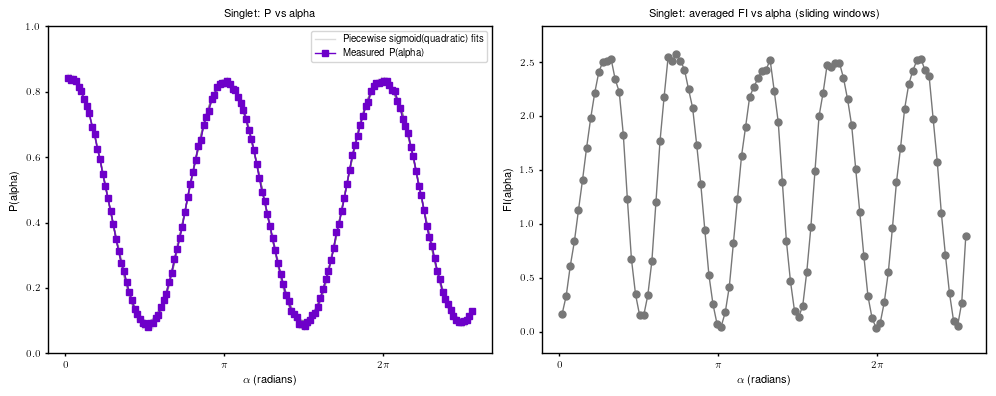

Saved singlet_Ux α,P,FI to: data_analysis/singlet_Ux_alpha_P_FI_1218_raw.csv


'data_analysis/singlet_Ux_alpha_P_FI_1218_raw.csv'

In [355]:
# ------------------ Apply readout matrix (raw) ------------------
P_Ux_raw = apply_readout_matrix_general(P_Ux, R_2q)
P_01_Ux_raw = P_Ux_raw[:, 1]

# ------------------ Run sliding-window FI analysis ------------------
res_Ux_raw = analyze_singlet_FI(
    alpha_data = alpha_data_Ux,     # alpha(t) from time fit
    P_01       = P_01_Ux_raw,       # raw P(α)
    alpha_window_size=0.8,
    step = 1,
    n_alpha_points = 300,
    make_plot = True
)

alpha_Ux_raw = res_Ux_raw["alpha_grid"]   # α grid after sliding window
FI_Ux_raw    = res_Ux_raw["FI_avg"]       # FI(α) averaged

# ------------------ Interpolate P(α) onto the new alpha grid ------------------
P_Ux_raw_interp = np.interp(
    alpha_Ux_raw,
    alpha_data_Ux,    # alpha(t)
    P_01_Ux_raw       # raw P(α)
)

# ------------------ Save ------------------
date_suffix_raw = "1218_raw"

save_dir = "data_analysis"
save_alpha_P_FI(
    basename   = "singlet_Ux",
    alpha      = alpha_Ux_raw,
    P          = P_Ux_raw_interp,
    FI         = FI_Ux_raw,
    save_dir   = save_dir,
    date_suffix = date_suffix_raw
)


## Singlet dataset (rotations about $\hat{y}$) — raw (uncorrected)

Same workflow as the $\hat{x}$ case, but for rotations about $\hat{y}$.


In [356]:
import os
import pandas as pd

# Directory containing the input CSV files.
# (load_directory set in the setup cell above)

# Experiment identifier and date tag used in the CSV filenames.
# The date tag (e.g. "1218") is part of the filename and does not affect the analysis logic.
exp_name_z = 'singlet_Uy'
date_suffix = '1218'  # Dataset tag used in the released filenames.

# Load readout-fidelity-corrected probability time series from CSV.
t_list_Uy = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_t_list_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Uy = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_P_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_01_Uy = P_Uy[:,1]  # interpret column 1 as P(|01⟩)



In [357]:
# 1) Convert experimental time samples t -> rotation angle α (radians)
# We fit a decaying cosine in time to infer the oscillation frequency Ω, then define α = Ω t / frequency_factor.
# The frequency_factor is a convention used in the original analysis notebooks (kept here for consistency).
frequency_factor = 2.0
initial_guess_global = [0.5, 0.025, 10000, 0.5]

alpha_data_Uy, tau_Uy, params_Uy = t_to_alpha_with_params(
    t_list_Uy,
    P_01_Uy,
    frequency_factor,
    initial_guess_global
)



/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_96763/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


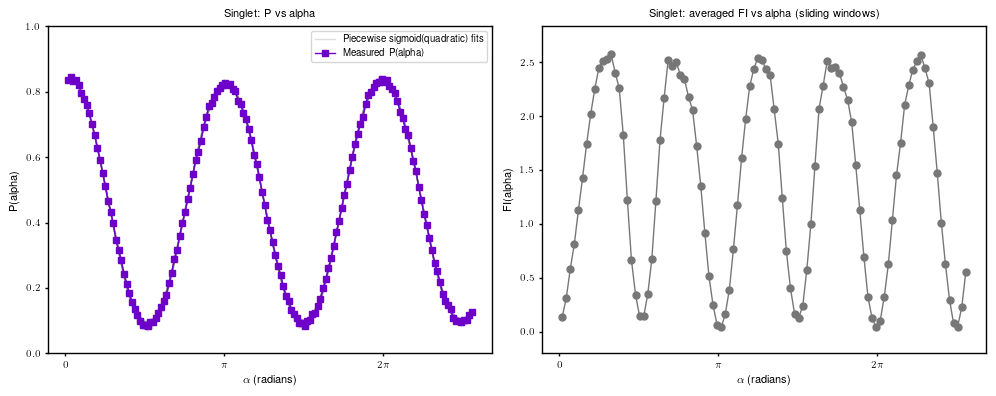

Saved singlet_Uy α,P,FI to: data_analysis/singlet_Uy_alpha_P_FI_1218_raw.csv


'data_analysis/singlet_Uy_alpha_P_FI_1218_raw.csv'

In [358]:
# ------------------ Apply readout matrix (raw) ------------------
P_Uy_raw = apply_readout_matrix_general(P_Uy, R_2q)
P_01_Uy_raw = P_Uy_raw[:, 1]

# ------------------ Run sliding-window FI analysis ------------------
res_Uy_raw = analyze_singlet_FI(
    alpha_data = alpha_data_Uy,     # alpha(t) from time fit
    P_01       = P_01_Uy_raw,       # raw P(α)
    alpha_window_size=0.8,
    step = 1,
    n_alpha_points = 300,
    make_plot = True
)

alpha_Uy_raw = res_Uy_raw["alpha_grid"]   # α grid after sliding window
FI_Uy_raw    = res_Uy_raw["FI_avg"]       # FI(α) averaged

# ------------------ Interpolate P(α) onto the new alpha grid ------------------
P_Uy_raw_interp = np.interp(
    alpha_Uy_raw,
    alpha_data_Uy,    # alpha(t)
    P_01_Uy_raw       # raw P(α)
)

# ------------------ Save ------------------
date_suffix_raw = "1218_raw"

save_dir = "data_analysis"
save_alpha_P_FI(
    basename   = "singlet_Uy",
    alpha      = alpha_Uy_raw,
    P          = P_Uy_raw_interp,
    FI         = FI_Uy_raw,
    save_dir   = save_dir,
    date_suffix = date_suffix_raw
)


## Singlet dataset (rotations about $\hat{z}$) — raw (uncorrected)

Same workflow as the $\hat{x}$ case, but for rotations about $\hat{z}$.


In [359]:
import os
import pandas as pd

# Directory containing the input CSV files.
# (load_directory set in the setup cell above)

# Experiment identifier and date tag used in the CSV filenames.
# The date tag (e.g. "1218") is part of the filename and does not affect the analysis logic.
exp_name_z = 'singlet_Uz'
date_suffix = '1218'  # Dataset tag used in the released filenames.

# Load readout-fidelity-corrected probability time series from CSV.
t_list_Uz = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_t_list_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Uz = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_P_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_01_Uz = P_Uz[:,1]  # interpret column 1 as P(|01⟩)



In [360]:
# 1) Convert experimental time samples t -> rotation angle α (radians)
# We fit a decaying cosine in time to infer the oscillation frequency Ω, then define α = Ω t / frequency_factor.
# The frequency_factor is a convention used in the original analysis notebooks (kept here for consistency).
frequency_factor = 2.0
initial_guess_global = [0.5, 0.025, 10000, 0.5]

alpha_data_Uz, tau_Uz, params_Uz = t_to_alpha_with_params(
    t_list_Uz,
    P_01_Uz,
    frequency_factor,
    initial_guess_global
)



/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_96763/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


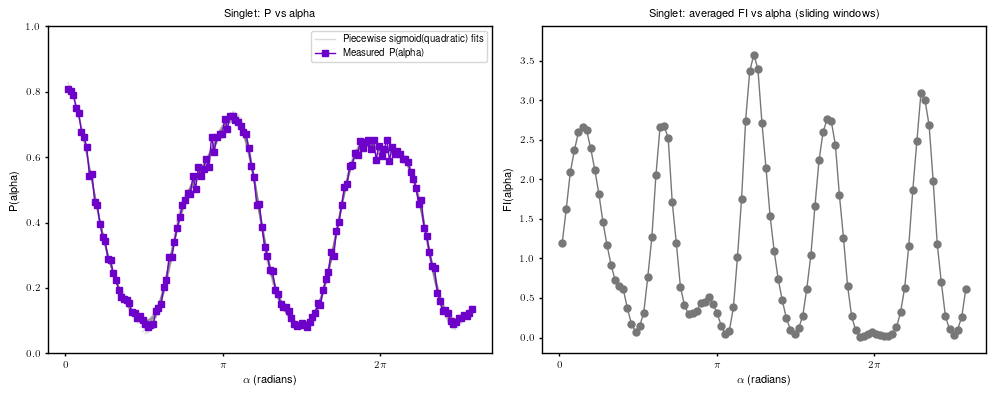

Saved singlet_Uz α,P,FI to: data_analysis/singlet_Uz_alpha_P_FI_1218_raw.csv


'data_analysis/singlet_Uz_alpha_P_FI_1218_raw.csv'

In [361]:
# ------------------ Apply readout matrix (raw) ------------------
P_Uz_raw = apply_readout_matrix_general(P_Uz, R_2q)
P_01_Uz_raw = P_Uz_raw[:, 1]

# ------------------ Run sliding-window FI analysis ------------------
res_Uz_raw = analyze_singlet_FI(
    alpha_data = alpha_data_Uz,     # alpha(t) from time fit
    P_01       = P_01_Uz_raw,       # raw P(α)
    alpha_window_size=0.8,
    step = 1,
    n_alpha_points = 300,
    make_plot = True
)

alpha_Uz_raw = res_Uz_raw["alpha_grid"]   # α grid after sliding window
FI_Uz_raw    = res_Uz_raw["FI_avg"]       # FI(α) averaged

# ------------------ Interpolate P(α) onto the new alpha grid ------------------
P_Uz_raw_interp = np.interp(
    alpha_Uz_raw,
    alpha_data_Uz,    # alpha(t)
    P_01_Uz_raw       # raw P(α)
)

# ------------------ Save ------------------
date_suffix_raw = "1218_raw"

save_dir = "data_analysis"
save_alpha_P_FI(
    basename   = "singlet_Uz",
    alpha      = alpha_Uz_raw,
    P          = P_Uz_raw_interp,
    FI         = FI_Uz_raw,
    save_dir   = save_dir,
    date_suffix = date_suffix_raw
)


## Raw-data figures (singlet Ux/Uy/Uz)

We build a shared α grid across the three raw singlet curves and plot the combined probability and FI panels.


In [362]:
import numpy as np

# -----------------------------
# Common alpha grid for singlet (raw)
# -----------------------------

def _prep_alpha_y(alpha, y):
    alpha = np.asarray(alpha, float)
    y = np.asarray(y, float)
    m = np.isfinite(alpha) & np.isfinite(y)
    alpha, y = alpha[m], y[m]
    order = np.argsort(alpha)
    return alpha[order], y[order]

Ux_a_P, Ux_P = _prep_alpha_y(alpha_Ux_raw, P_Ux_raw_interp)
Uy_a_P, Uy_P = _prep_alpha_y(alpha_Uy_raw, P_Uy_raw_interp)
Uz_a_P, Uz_P = _prep_alpha_y(alpha_Uz_raw, P_Uz_raw_interp)

Ux_a_FI, Ux_FI = _prep_alpha_y(alpha_Ux_raw, FI_Ux_raw)
Uy_a_FI, Uy_FI = _prep_alpha_y(alpha_Uy_raw, FI_Uy_raw)
Uz_a_FI, Uz_FI = _prep_alpha_y(alpha_Uz_raw, FI_Uz_raw)

alpha_min_overlap = max(np.nanmin(Ux_a_P), np.nanmin(Uy_a_P), np.nanmin(Uz_a_P))
alpha_max_overlap = min(np.nanmax(Ux_a_P), np.nanmax(Uy_a_P), np.nanmax(Uz_a_P))
if not (alpha_max_overlap > alpha_min_overlap):
    raise ValueError("No overlap among alpha grids for Ux/Uy/Uz.")

N_common = min(len(Ux_a_P), len(Uy_a_P), len(Uz_a_P))
alpha_common = np.linspace(alpha_min_overlap, alpha_max_overlap, N_common)

alpha_xlim_min = alpha_min_overlap
alpha_xlim_max = alpha_max_overlap

P_Ux_common = np.interp(alpha_common, Ux_a_P, Ux_P)
P_Uy_common = np.interp(alpha_common, Uy_a_P, Uy_P)
P_Uz_common = np.interp(alpha_common, Uz_a_P, Uz_P)

FI_Ux_common = np.interp(alpha_common, Ux_a_FI, Ux_FI)
FI_Uy_common = np.interp(alpha_common, Uy_a_FI, Uy_FI)
FI_Uz_common = np.interp(alpha_common, Uz_a_FI, Uz_FI)

FI_mean_common = (FI_Ux_common + FI_Uy_common + FI_Uz_common) / 3.0

DOWNSAMPLE_FRAC = 0.7
n = len(alpha_common)
_m = max(2, int(round(DOWNSAMPLE_FRAC * n)))
idx_ds = np.linspace(0, n - 1, _m).astype(int)

alpha_common_ds = alpha_common[idx_ds]

P_Ux_ds = P_Ux_common[idx_ds]
P_Uy_ds = P_Uy_common[idx_ds]
P_Uz_ds = P_Uz_common[idx_ds]

FI_Ux_ds = FI_Ux_common[idx_ds]
FI_Uy_ds = FI_Uy_common[idx_ds]
FI_Uz_ds = FI_Uz_common[idx_ds]

FI_mean_ds = FI_mean_common[idx_ds]



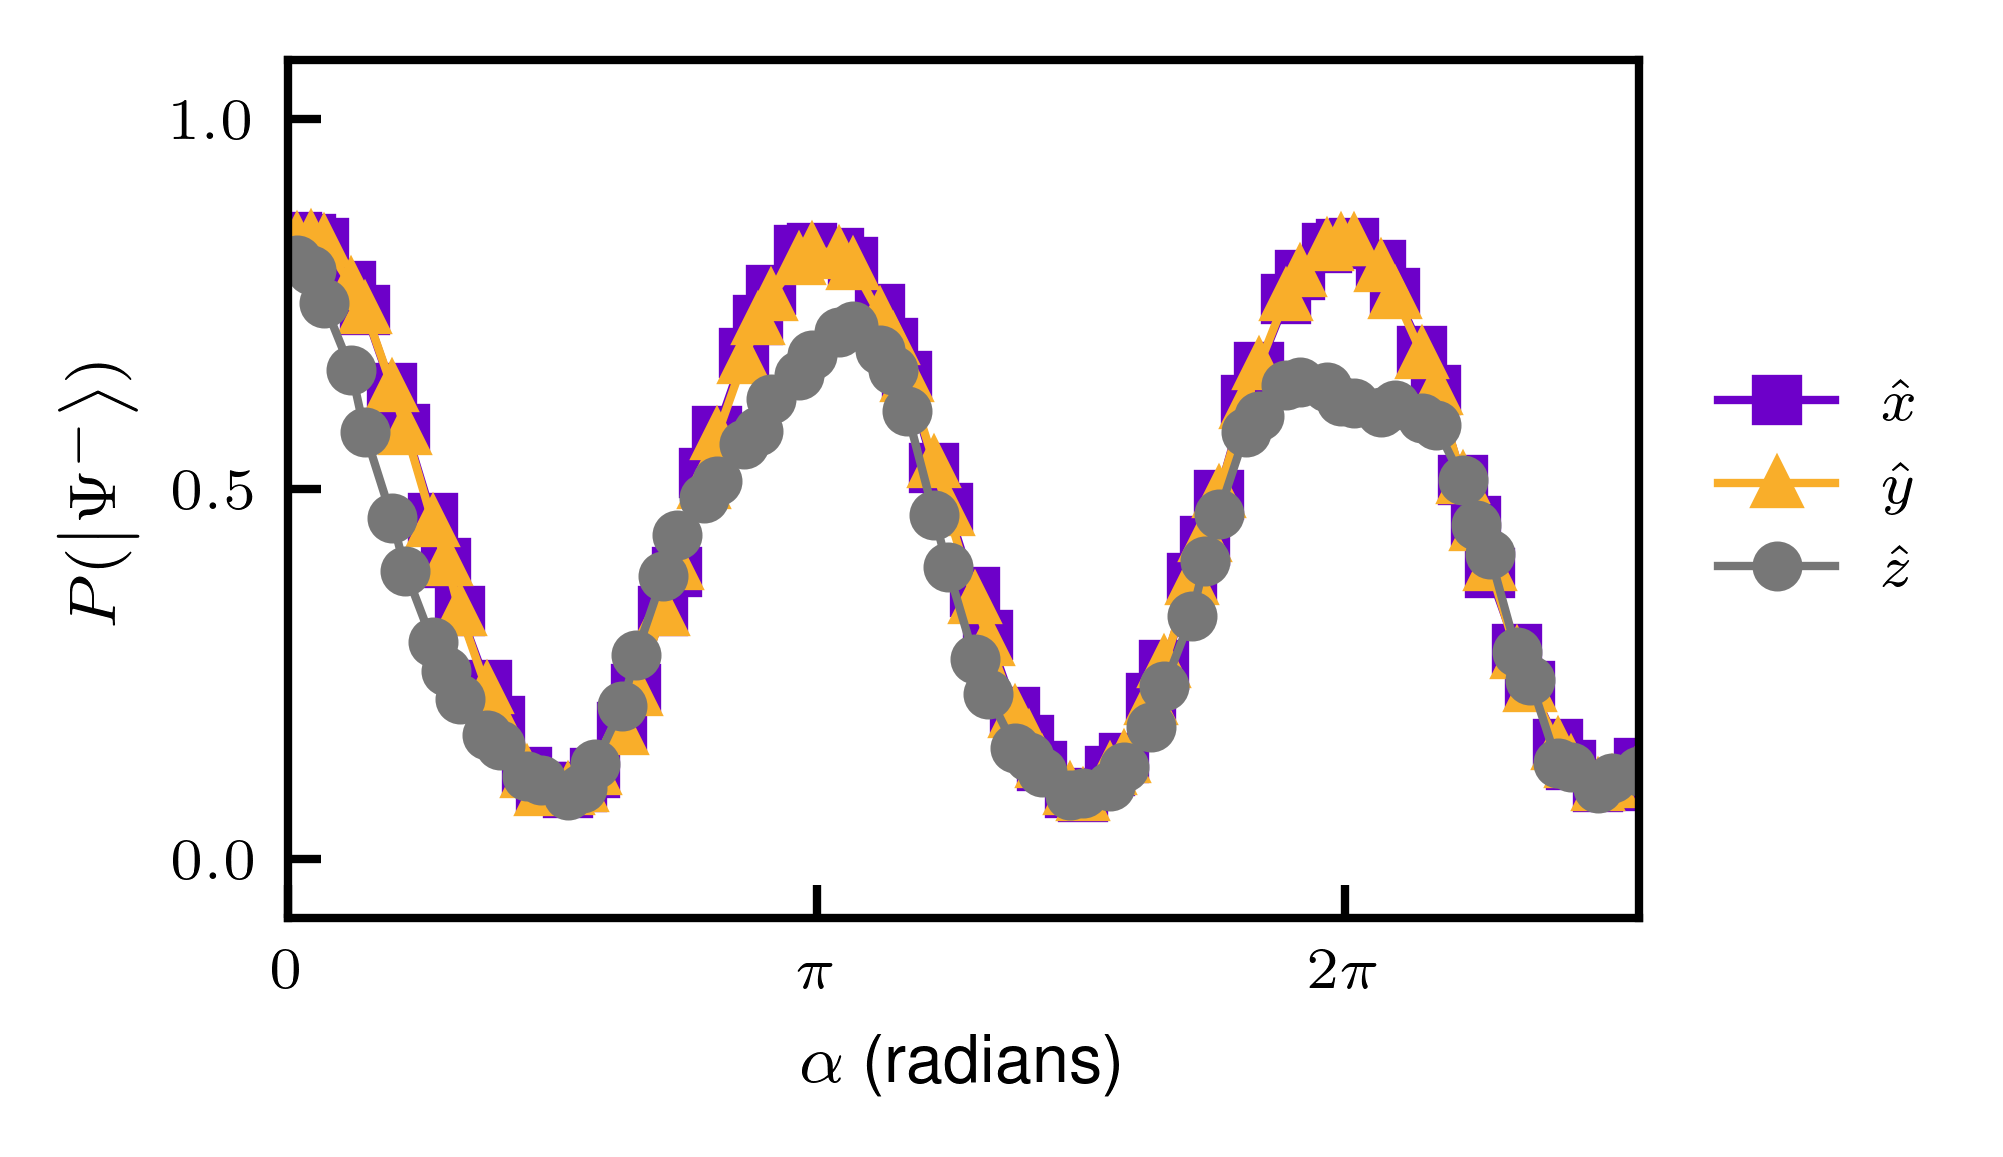

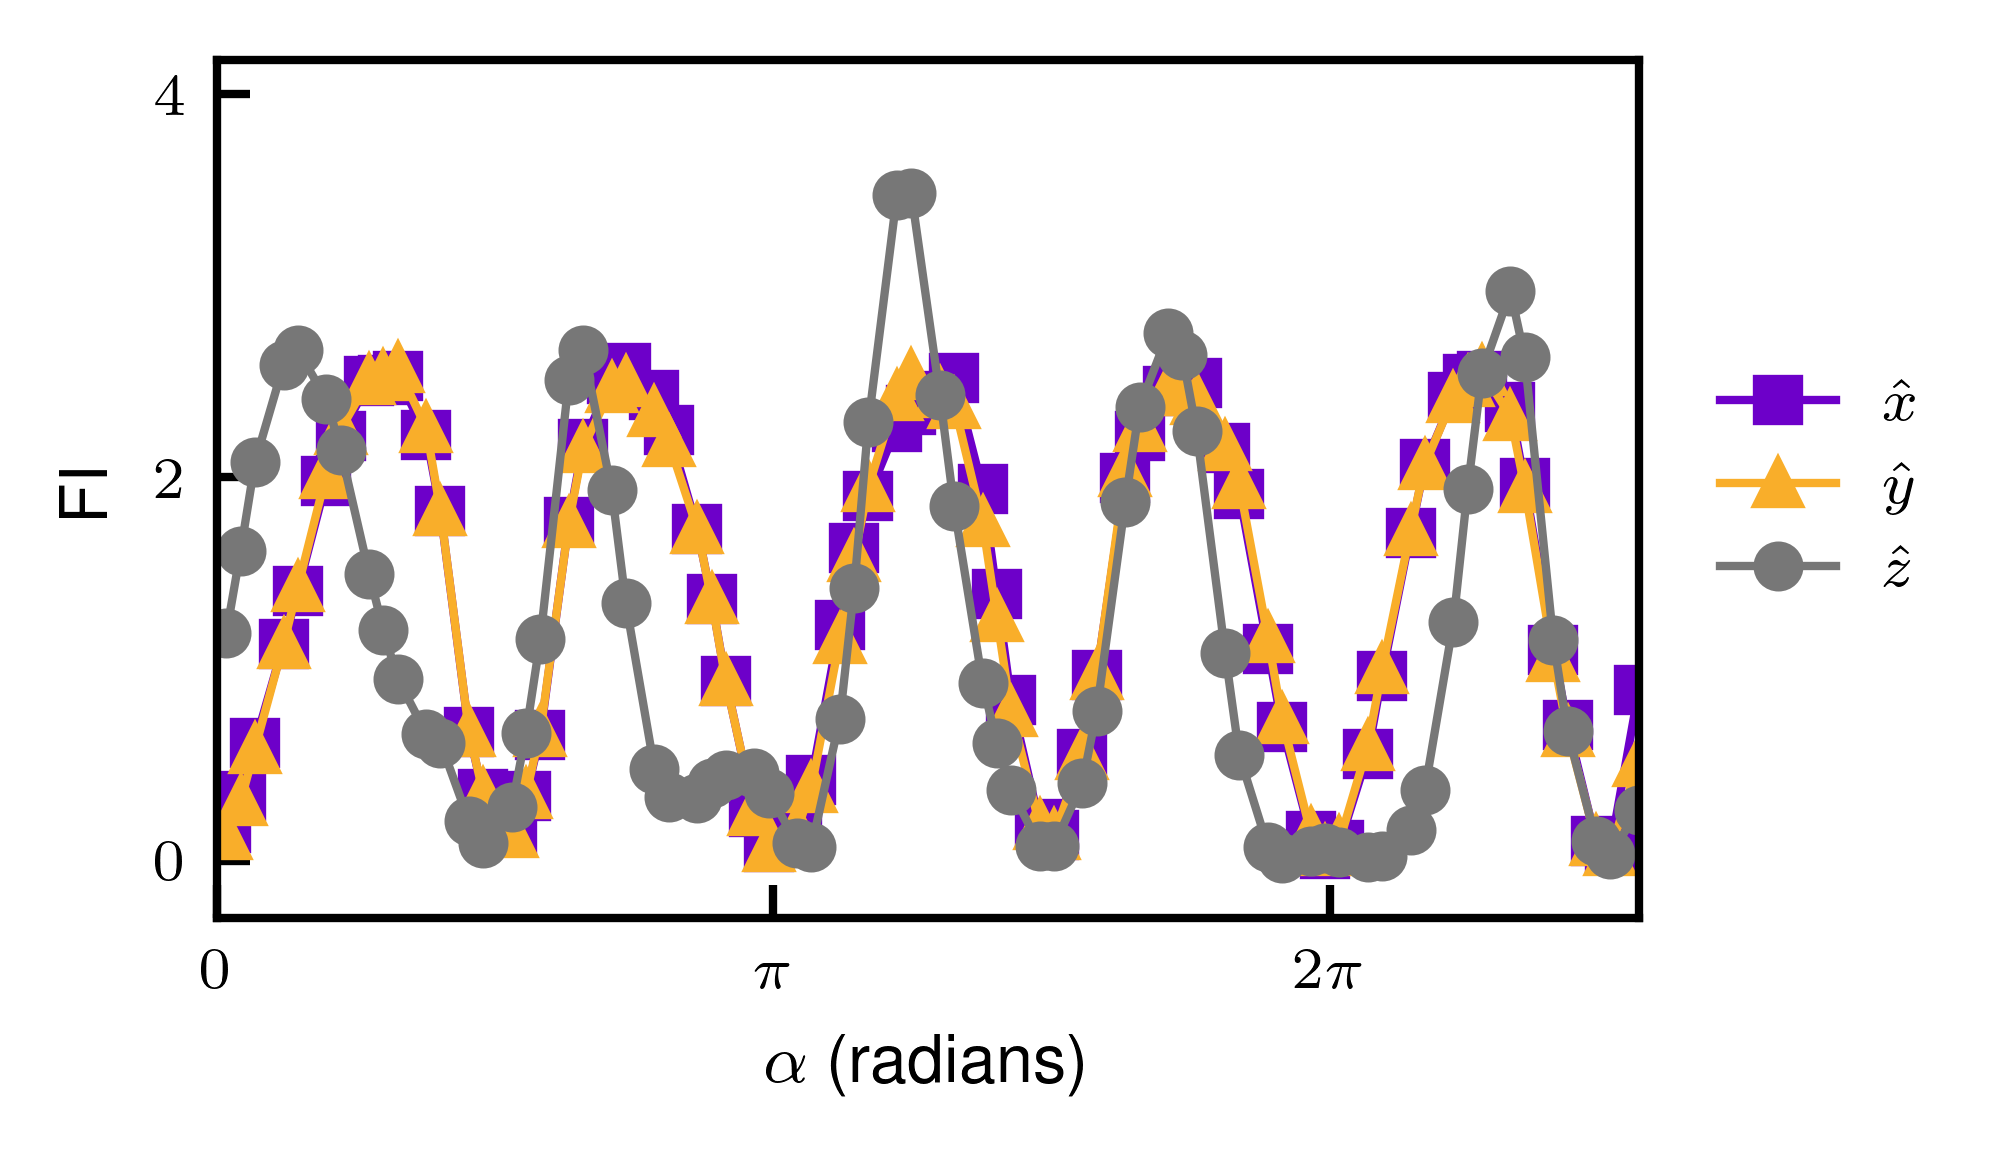

In [363]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# P(|Psi->) combined (raw)
fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, P_Ux_ds, **style_x)
ax.plot(alpha_common_ds, P_Uy_ds, **style_y)
ax.plot(alpha_common_ds, P_Uz_ds, **style_z)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.08, 1.08)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 0.5, 1])
ax.set_xlabel(r"$\alpha$ (radians)")
ax.set_ylabel(fr"$P({ket_psi})$")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ticks inside the frame
ax.tick_params(axis="both", which="both", direction="in")
ax.tick_params(axis="x", which="major", bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction="in")
ax.tick_params(axis="y", which="major", left=True, right=False, labelleft=True,
               length=4, width=lw, direction="in")

fig.tight_layout()
plt.show()

# FI combined (raw)
fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, FI_Ux_ds, **style_x)
ax.plot(alpha_common_ds, FI_Uy_ds, **style_y)
ax.plot(alpha_common_ds, FI_Uz_ds, **style_z)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.3, 4.18)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 2, 4])
ax.set_xlabel(r"$\alpha$ (radians)")
ax.set_ylabel("FI")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ticks inside the frame
ax.tick_params(axis="both", which="both", direction="in")
ax.tick_params(axis="x", which="major", bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction="in")
ax.tick_params(axis="y", which="major", left=True, right=False, labelleft=True,
               length=4, width=lw, direction="in")

fig.tight_layout()
plt.show()







## Raw-data average FI (singlet)

We average FI across the three rotation axes using the shared α grid defined above, then plot the mean curve and its average value.


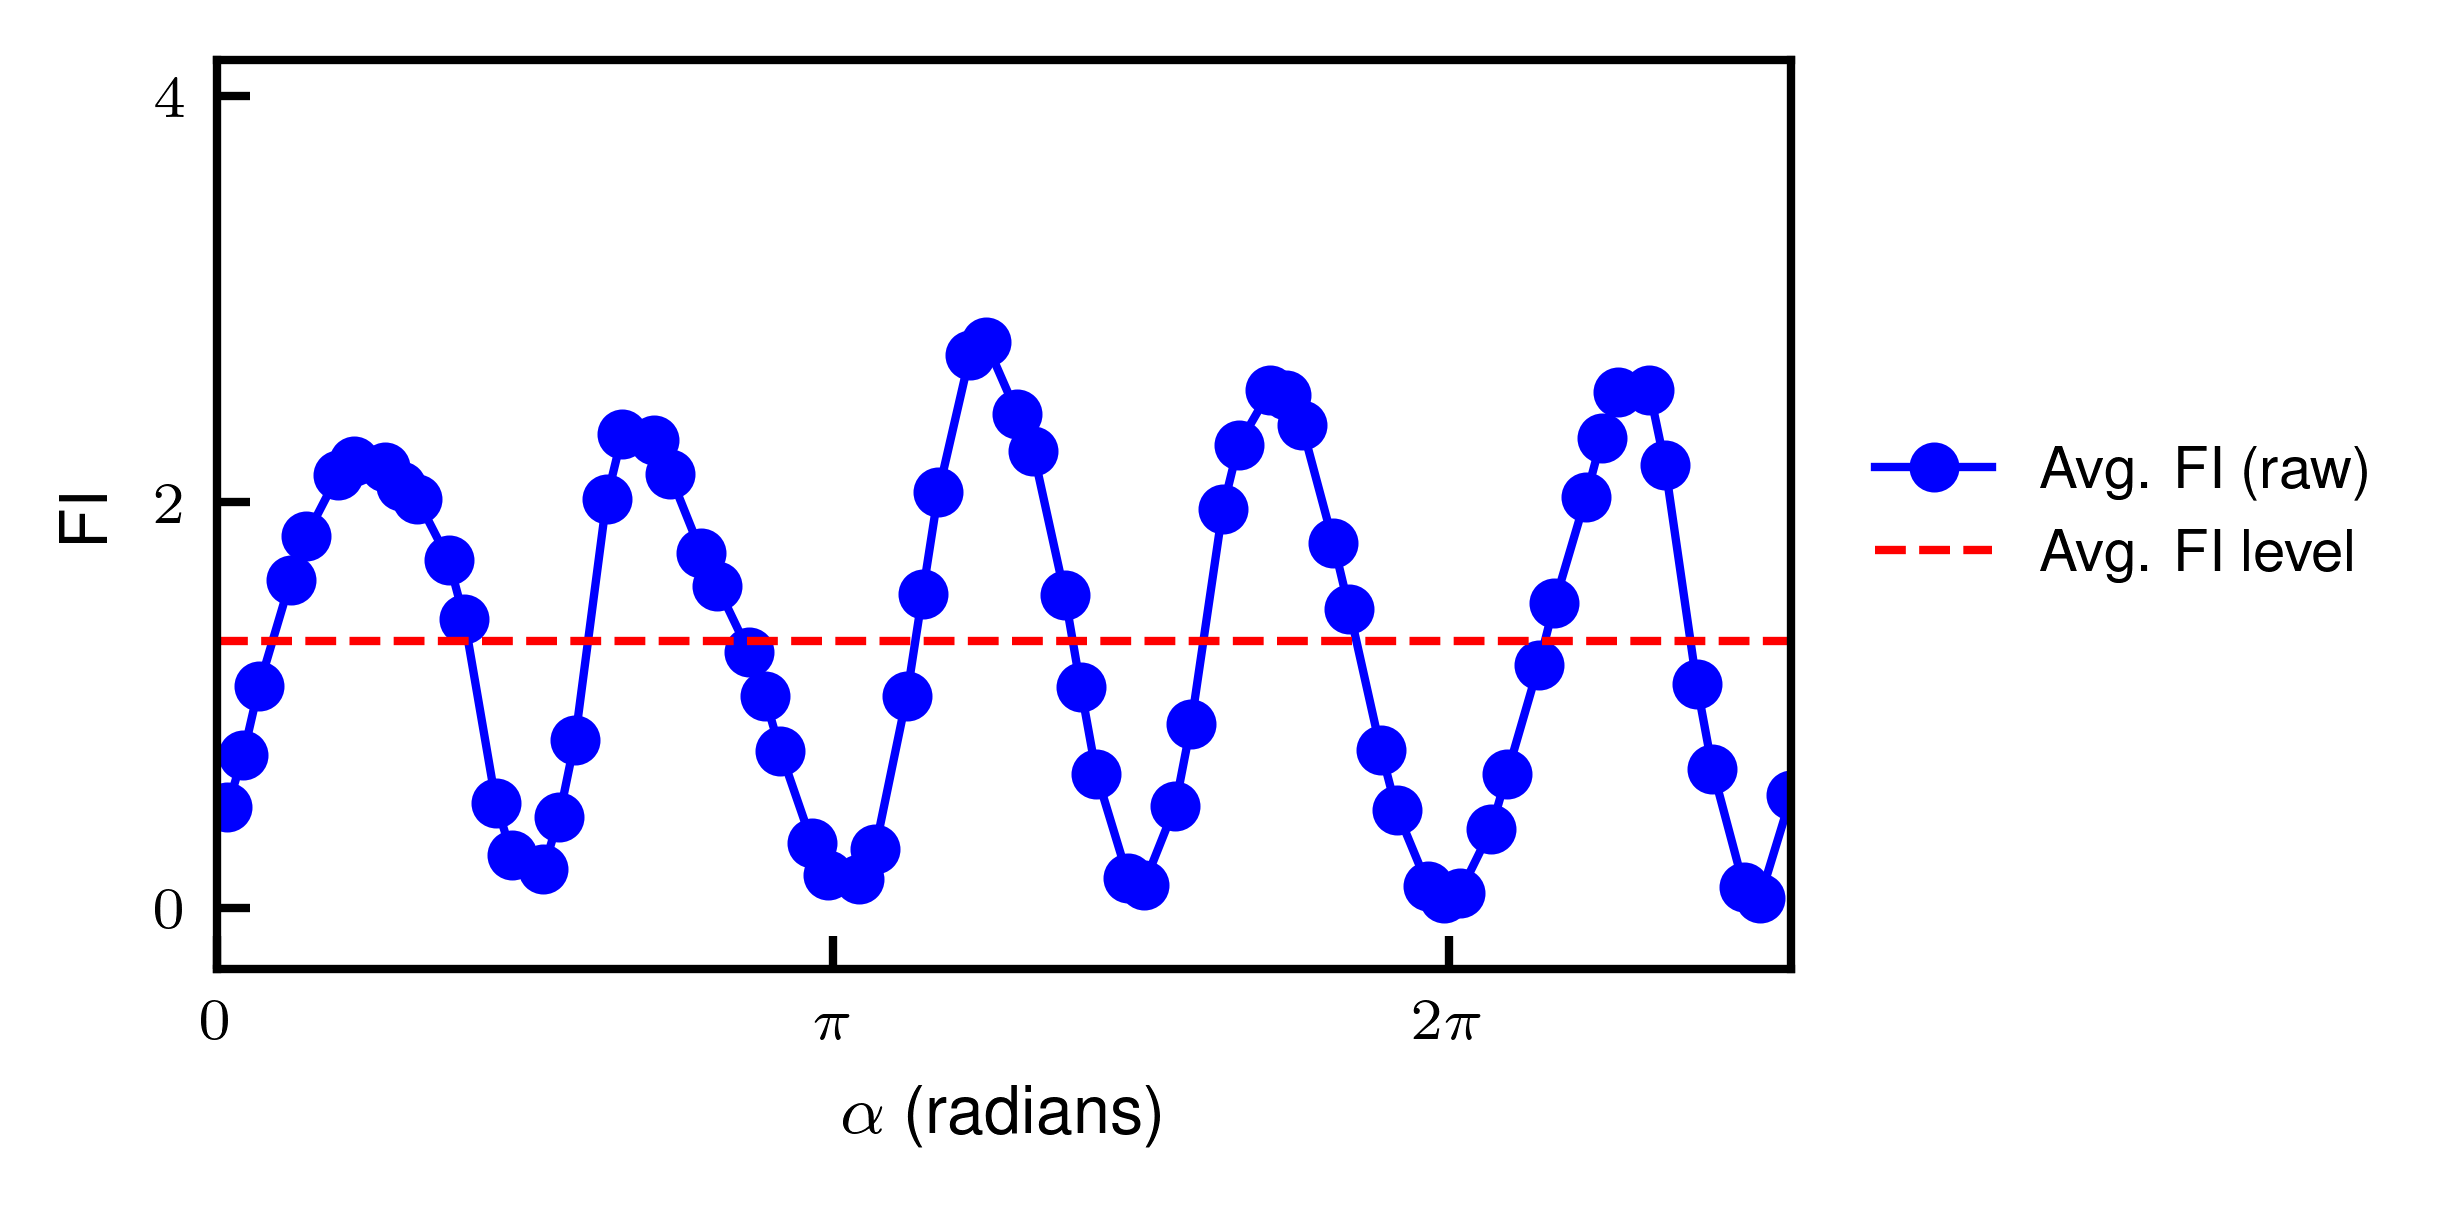

1.3154362875172214


In [364]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

style_mean = dict(color="blue", marker="o", linestyle="-", markersize=5.0, label=r"Avg. FI (raw)")
style_hline = dict(color="red", linestyle="--", linewidth=1.0, label="Avg. FI level")

singlet_Uxyz_mean_FI_ds_raw = FI_mean_ds
singlet_FI_ds_raw_mean = np.mean(singlet_Uxyz_mean_FI_ds_raw)

fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, singlet_Uxyz_mean_FI_ds_raw, **style_mean)
ax.axhline(singlet_FI_ds_raw_mean, **style_hline)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.3, 4.18)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 2, 4])
ax.set_xlabel(r"$\alpha$ (radians)")
ax.set_ylabel("FI")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

ax.tick_params(axis="both", which="both", direction="in")
ax.tick_params(axis="x", which="major", bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction="in")
ax.tick_params(axis="y", which="major", left=True, right=False, labelleft=True,
               length=4, width=lw, direction="in")

outpath = os.path.join("si_figures", "SI_fig_v3_b_raw.pdf")
os.makedirs(os.path.dirname(outpath), exist_ok=True)
fig.savefig(outpath, bbox_inches="tight")
plt.show()

print(singlet_FI_ds_raw_mean)

